# **Проект для «Викишоп» с BERT**

Для интернет-магазина «Викишоп», который запускает новый сервис - возможность редактировать и дополнять описания товаров для пользователей, как в вики-сообществах, необходим инструмент для поиска и определения токсичных комментариев, чтобы отправлять их на модерацию.

**Цель:** построить модель, классифицирующую комментарии на токсичные и нетоксичные. Значение F1 должно быть не меньше 0.75.

**Описание данных**

Файл `toxic_comments.csv` хранит данные с разметкой о токсичности правок: столбец `text` содержит комментарий, столбец `toxic` указывает, является ли комментарий токсичным.

**Ход исследования**
1. Изучение данных и их преобразование: удаление стоп-слов, очистка текста
2. Обучение моделей с различными гиперпараметрами
3. Проверка результата на тестовой выборке
4. Вывод

In [1]:
pip install optuna

In [2]:
pip install optuna-integration[sklearn]

In [3]:
import optuna
import spacy
import re
import torch

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV

from optuna.distributions import FloatDistribution, IntDistribution, CategoricalDistribution
from optuna.integration import OptunaSearchCV

from sklearn.metrics import f1_score
from sklearn.metrics import precision_recall_curve

from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords
import nltk

from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import PassiveAggressiveClassifier
from sklearn.dummy import DummyClassifier

from transformers import pipeline

In [4]:
try:
    df = pd.read_csv('/datasets/toxic_comments.csv').drop('Unnamed: 0', axis=1)
except:
    df = pd.read_csv('https://code.s3.yandex.net/datasets/toxic_comments.csv').drop('Unnamed: 0', axis=1)

In [5]:
df.info()

In [6]:
pd.set_option('display.max_colwidth', None)
df.head(10)

In [7]:
df.isna().sum()

In [8]:
df.duplicated().sum()

In [9]:
df.toxic.value_counts(1)

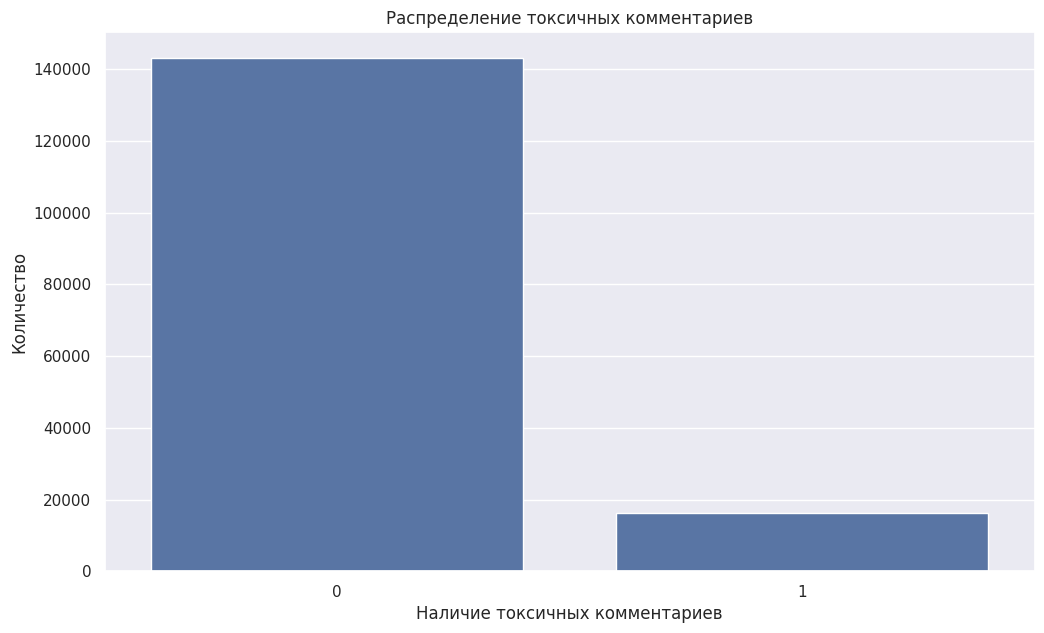

In [10]:
sns.set_style('darkgrid')
sns.set(rc={'figure.figsize': (12, 7)})
sns.countplot(data=df, x='toxic').set(title='Распределение токсичных комментариев', xlabel='Наличие токсичных комментариев', ylabel='Количество');
sns.set_style('darkgrid')

**Промежуточный вывод:**

- Был предоставлен набор данных с примерно 160 тысячами строк
- Текст комментариев на английском языке
- Пропусков нет
- Явных дубликатов нет
- При загрузке удалён лишний столбец.
- Целевой признак распределен неравномерно: 9 к 1, что будем учитывать при создании модели
- Текст содержит в себе лишние символы, от которых лучше избавиться

## Подготовка данных

In [11]:
# скачаем базовую модель для английского языка
nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])

In [12]:
# очистим текст от лишних символов
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[\n\r]', ' ', text)
    text = re.sub(r'[^a-z\s]', '', text)
    return text.strip()

df['clean'] = df['text'].apply(clean_text)

df.head()

In [13]:
# приведём слова к начальной форме
def lemmatize(text):
    return ' '.join([token.lemma_ for token in nlp(text)])

df['lemm'] = df['clean'].apply(lemmatize)
df.head()

In [14]:
# разделим данные на выборки
X = df['lemm']
y = df['toxic']

#
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [15]:
# загрузим слова без смысловой нагрузки английского языка - стоп-слова
nltk.download('stopwords')
stops = set(stopwords.words('english'))

**Промежуточный вывод:**
- Из текста комментариев были удалены лишние символы
- Слова были приведены в начальную форму
- Были загружены стоп-слова для дальнейшего использования в моделях

## Подбор и обучение моделей

Рассмотрим три модели: логистическую регрессию, пассивно-агрессивный классификатор и BERT. Чтобы избежать утечки данных, используем пайплайн. Для логистической регрессии и пассивно-агрессивной классификации подберём гиперпараметры. Выделим также валидационную выборку для проверки результата.

In [16]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.25,
    random_state=42,
    stratify=y_train
)

### Логистическая регрессия

In [17]:
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english')),
    ('model', LogisticRegression(random_state=42))
])

In [19]:
param_distributions = {
    'tfidf__max_features': IntDistribution(1000, 10000),
    'model__C': FloatDistribution(1e-3, 10, log=True),
    'model__max_iter': IntDistribution(500, 2000)
}

optuna_search = OptunaSearchCV(
    pipeline,
    param_distributions,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    n_trials=50,
    random_state=42,
    verbose=1
)

optuna_search.fit(X_train, y_train)

In [20]:
print("Best parameters:", optuna_search.best_params_)
print("Best F1 score:", optuna_search.best_score_)

In [21]:
lr_pred = optuna_search.predict(X_val)

f1_lr = f1_score(y_val, lr_pred)

print('F1 равен:', round(f1_lr, 2))

### Пассивно-агрессивная классификация

In [22]:
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english', max_df=0.8, min_df=2, max_features=10000)),
    ('clf', PassiveAggressiveClassifier(random_state=42))
])

In [23]:
param_grid = {
    'tfidf__max_features': [5000, 10000, 15000],
    'clf__C': [0.01, 0.1, 1, 10],
    'clf__max_iter': [50, 100, 200],
    'clf__loss': ['hinge', 'squared_hinge']
}

halving_search = HalvingGridSearchCV(
    pipeline,
    param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    aggressive_elimination=True,
    random_state=42
)

halving_search.fit(X_train, y_train)

print("Лучшие параметры:", halving_search.best_params_)
print("Лучший F1-score:", halving_search.best_score_)

In [24]:
pac_pred = halving_search.predict(X_val)

f1_pac = f1_score(y_val, pac_pred)

print('F1 равен:', round(f1_pac, 2))

### BERT

Для экономии времени используем уже обученную модель Hugging Face.

In [25]:
from transformers import pipeline

classifier = pipeline(
    task="sentiment-analysis",
    model='unitary/toxic-bert',
    device=0 if torch.cuda.is_available() else -1,
    batch_size=32,
    truncation=True,
    padding=True
)

In [26]:
preds_val = classifier(X_val.to_list(), padding=True, max_length=256, truncation=True)
scores = pd.DataFrame(preds_val)['score'].values

In [27]:
# найдём оптимальный порог
precision, recall, thresholds = precision_recall_curve(y_val, scores)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-9)
best_threshold = thresholds[np.argmax(f1_scores)]

y_pred_bert = (scores >= best_threshold).astype(int)
print("Лучший F1:", f1_score(y_val, y_pred_bert))
print("Лучший порог:", best_threshold)
f1_bert_val = f1_score(y_val, y_pred_bert)

Лучше всего себя показала модель BERT. Проверим результаты на адекватность с помощью Dummy-моделей.

### Dummy

Будем использовать 2 типа:

1) показывает наиболее частое значение (0), то есть предсказание по умолчанию  
2) всегда предсказывает положительный класс, то есть всегда ставит 1

In [28]:
dm_f = DummyClassifier(strategy='most_frequent', random_state=42)
dm_f.fit(X_train, y_train)
y_pred_dm_f = dm_f.predict(X_test)
f1_dm_f = f1_score(y_test, y_pred_dm_f)
f1_dm_f

In [31]:
dm_cp = DummyClassifier(strategy='constant', constant=1, random_state=42)
dm_cp.fit(X_train, y_train)
y_pred_dm_cp = dm_cp.predict(X_test)
f1_dm_cp = f1_score(y_test, y_pred_dm_cp)
f1_dm_cp

Все модели достигли требуемого качества при поиске токсичных комментариев. Сведём результаты на валидационной выборке в таблицу.

In [32]:
res = pd.DataFrame([[round(f1_lr, 2)],
                      [round(f1_pac, 2)],
                      [round(f1_bert_val, 2)],
                      [round(f1_dm_f, 2)],
                      [round(f1_dm_cp, 2)]],
                     columns=['F1'],
                     index=['LogisticRegression', 'PassiveAggressiveClassifier', 'BERT', 'DummyRegression_mf', 'DummyRegression_cp'])
res

**Промежуточный вывод**
- При разделении данных на выборки был учтен дисбаланс классов
- Были подобраны гиперпараметры для логистической регрессии и пассивно-агрессивного классификатора, из этих двух моделей на валидационной выборке лучший результат показала логистическая регрессия
- Адекватность задействованных моделей подтвердилась результатом Dummy-модели, чей результат значительно хуже специально подобранных моделей.
- Лучший результат показала модель BERT: `F1 = 0.90`.

## Тестирование

Получим результат на тестовой выборке.

In [33]:
preds = classifier(X_test.to_list(), padding=True, max_length=256, truncation=True)
scores = pd.DataFrame(preds)['score'].values

In [34]:
y_pred_bert = (scores >= best_threshold).astype(int)
f1_bert = f1_score(y_test, y_pred_bert)
print("Лучший F1:", f1_bert)

Таким образом, лучшим решением для поставленной задачи является модель BERT с F1 = 0.90 на тестовой выборке.

## Вывод

*Рекомендация*
- Заказчику для задачи определения токсичных комментариев на английском языке рекомендуется **модель BERT**, поскольку она дает лучший результат среди проверенных моделей, её метрика **F1 = 0.90**

*Предобработка*
- Целевой признак оказался несбалансированным, пропусков и явных дубликатов в изначальной выборке не было.
- Текст комментария был очищен от лишних символов, а слова приведены в начальную форму.
- Была применена TF-IDF векторизация

*Модели*
- Все рассмотренные модели дали результат, удовлетворяющий условиям заказчика, после подбора гиперпараметров их метрика F1 была выше 0.75, в частности
  - LR - 0.77
  - PAC - 0.78
- Лучшей моделью оказалась BERT с порогом около 0.5.
- Все модели прошли проверку на адекватность при сравнении с результатом Dummy-модели.